In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [ ]:
#this script allows plotting of the relevant abundance of proteins as a heatmap

#pass the list of conditions you want to plot as a list

#specify the genes you want to show in the heatmap as a list


def plot_abundance_heatmap(input_file, output_dir, output_filename, gene_subset, timepoint_cols, vmin=None, vmax=None):
    df = pd.read_csv(input_file)

    # Handle NaNs in Gene column
    mask = df['Gene'].apply(lambda x: isinstance(x, str) and any(gene in x.split(';') for gene in gene_subset))
    df_filtered = df[mask].copy()

    # Create unique Heatmap ID
    # Use the full semicolon-separated gene entry as the label
    def make_id(row):
        return row['Gene'] if isinstance(row['Gene'], str) else "Unknown"


    df_filtered['Heatmap_ID'] = df_filtered.apply(make_id, axis=1)

    heatmap_data = df_filtered.set_index('Heatmap_ID')[timepoint_cols]

    # Axis labels
    display_names = {
        'MUT_dTAG_1h': 'dTAG 1h',
        'MUT_dTAG_6h': 'dTAG 6h',
        'MUT_dTAG_24h': 'dTAG 24h',
        'MUT_dTAG_48h': 'dTAG 48h'
    }
    heatmap_data = heatmap_data.rename(columns=display_names)

    # Output paths
    os.makedirs(output_dir, exist_ok=True)
    png_path = os.path.join(output_dir, f"{output_filename}.png")
    pdf_path = os.path.join(output_dir, f"{output_filename}.pdf")

    # Reorder heatmap rows to match gene_subset order
    def extract_gene_id(row_label):
        genes = row_label.split(';')
        for gene in gene_subset:
            if gene in genes:
                return gene  # use the first match from gene_subset
        return None

    heatmap_data["__gene_sort_order__"] = heatmap_data.index.map(extract_gene_id)
    heatmap_data = heatmap_data.sort_values(by="__gene_sort_order__", key=lambda col: [gene_subset.index(g) if g in gene_subset else float('inf') for g in col])
    heatmap_data = heatmap_data.drop(columns="__gene_sort_order__")

    data_min = heatmap_data.min().min()
    data_max = heatmap_data.max().max()
    print(f"Heatmap value range: min = {data_min:.3f}, max = {data_max:.3f}")

    # Plot
    plt.figure(figsize=(8, 0.6 * len(heatmap_data)))
    midpoint = (vmin + vmax) / 2
    norm = TwoSlopeNorm(vmin=vmin, vcenter=midpoint, vmax=vmax)
   
    ax = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".6g",
        cmap="RdBu_r",
        linewidths=0.5,
        linecolor='black',
        cbar_kws={"label": "Log2 fold change"},
        norm=norm,
        annot_kws={"fontsize": 8}
    )


    plt.xticks(rotation=45, ha='right')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticklabels(ax.get_yticklabels(), weight='bold')
    plt.tight_layout()

    #plt.savefig(png_path, dpi=300)
    #plt.savefig(pdf_path)
    plt.show()


Heatmap value range: min = -0.966, max = 0.155


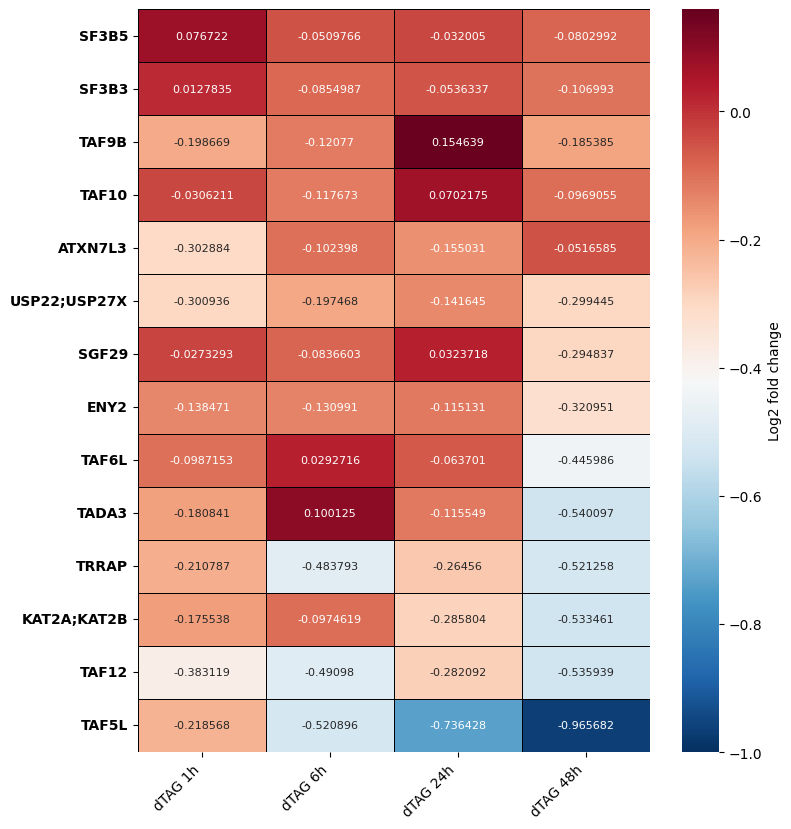

In [ ]:
input_file = "/input_dir/input_for_volcano_plot_merged_reps.csv"
output_dir = "/output_dir/plots/heatmaps"
output_filename = "mutant_abundance_heatmap"

# Timepoint abundance columns
conditions = ['MUT_dTAG_1h', 'MUT_dTAG_6h', 'MUT_dTAG_24h', 'MUT_dTAG_48h']

# Proteins of interest
gene_subset = ['SF3B5', 'SF3B3', 'TAF9B', 'TAF10', 'ATXN7L3', 'USP22', 'ATXN7', 'TADA2B',
 'SUPT20H', 'SUPT7L', 'SGF29', 'ENY2', 'TAF6L', 'TADA3', 'TRRAP', 'KAT2A',
 'TAF12', 'TAF5L']
              
# Call the function
plot_abundance_heatmap(
    input_file=input_file,
    output_dir=output_dir,
    output_filename="subset_mutant_abundance_heatmap_afmhot",
    gene_subset=gene_subset,
    timepoint_cols=conditions,
    vmin=-1,
    vmax=0.16
)

